In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [4]:
df = pd.read_csv("lung_cancer.csv")
target_col = "lung_cancer_risk"

X = df.drop(columns=[target_col])
y = df[target_col]

### Data Exploration

Let's start by inspecting the loaded data. I'll display the first few rows of the features (`X`) and the target (`y`), check their data types, and view descriptive statistics.

In [ ]:
print("First 5 rows of features (X):")
display(X.head())

print("\nFirst 5 rows of target (y):")
display(y.head())

In [ ]:
print("\nData types of features (X):")
display(X.info())

print("\nData types of target (y):")
display(y.info())

In [ ]:
print("\nDescriptive statistics for features (X):")
display(X.describe())

print("\nValue counts for target (y):")
display(y.value_counts())

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train positive rate:", y_train.mean(), "Test positive rate:", y_test.mean())

Train: (4000, 29) Test: (1000, 29)
Train positive rate: 0.24875 Test positive rate: 0.249


In [5]:
# Binary/categorical indicator columns. I am treating these as categorical to make easier for myself
cat_features = [
    "gender", "smoker", "passive_smoking", "occupational_exposure", "radon_exposure",
    "family_history_cancer", "copd", "asthma", "previous_tb", "chronic_cough",
    "chest_pain", "shortness_of_breath", "fatigue", "xray_abnormal"
]

# Everything else treated as numeric
num_features = [c for c in X.columns if c not in cat_features]

print("Categorical:", cat_features)
print("Numeric:", num_features)

Categorical: ['gender', 'smoker', 'passive_smoking', 'occupational_exposure', 'radon_exposure', 'family_history_cancer', 'copd', 'asthma', 'previous_tb', 'chronic_cough', 'chest_pain', 'shortness_of_breath', 'fatigue', 'xray_abnormal']
Numeric: ['age', 'education_years', 'income_level', 'smoking_years', 'cigarettes_per_day', 'pack_years', 'air_pollution_index', 'bmi', 'oxygen_saturation', 'fev1_x10', 'crp_level', 'exercise_hours_per_week', 'diet_quality', 'alcohol_units_per_week', 'healthcare_access']


In [6]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ],
    remainder="drop"
)

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [8]:
pipe_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

pipe_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

pipe_hgb = Pipeline(steps=[
    ("prep", preprocess),
    ("model", HistGradientBoostingClassifier(random_state=42))
])

In [10]:
#Logistic Regression

param_lr = {
    "model__C": np.logspace(-3, 3, 20),
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

search_lr = RandomizedSearchCV(
    pipe_lr,
    param_distributions=param_lr,
    n_iter=20,
    scoring="average_precision",  # PR-AUC
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_lr.fit(X_train, y_train)
print("Best LR PR-AUC (CV):", search_lr.best_score_)
print("Best LR params:", search_lr.best_params_)

Best LR PR-AUC (CV): 0.9996782551455764
Best LR params: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': np.float64(112.88378916846884)}


In [11]:
# Random Forest

param_rf = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

search_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_rf,
    n_iter=25,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_rf.fit(X_train, y_train)
print("Best RF PR-AUC (CV):", search_rf.best_score_)
print("Best RF params:", search_rf.best_params_)

Best RF PR-AUC (CV): 0.985703080384917
Best RF params: {'model__n_estimators': 600, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [12]:
#HGB Tuning

param_hgb = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [None, 3, 5, 7],
    "model__max_iter": [200, 400, 800],
    "model__min_samples_leaf": [10, 20, 50, 100]
}

search_hgb = RandomizedSearchCV(
    pipe_hgb,
    param_distributions=param_hgb,
    n_iter=25,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_hgb.fit(X_train, y_train)
print("Best HGB PR-AUC (CV):", search_hgb.best_score_)
print("Best HGB params:", search_hgb.best_params_)

Best HGB PR-AUC (CV): 0.9945449223423386
Best HGB params: {'model__min_samples_leaf': 20, 'model__max_iter': 800, 'model__max_depth': 5, 'model__learning_rate': 0.1}


In [13]:
# compare the 3 mdoels

def evaluate_model(model, X_test, y_test):
    # Probability scores for PR-AUC / ROC-AUC
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    roc = roc_auc_score(y_test, y_proba)
    pr = average_precision_score(y_test, y_proba)

    # Default threshold 0.5
    y_pred = (y_proba >= 0.5).astype(int)

    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {"ROC_AUC": roc, "PR_AUC": pr, "Precision": prec, "Recall": rec, "F1": f1}

best_lr = search_lr.best_estimator_
best_rf = search_rf.best_estimator_
best_hgb = search_hgb.best_estimator_

results = pd.DataFrame({
    "LogReg": evaluate_model(best_lr, X_test, y_test),
    "RandForest": evaluate_model(best_rf, X_test, y_test),
    "HistGB": evaluate_model(best_hgb, X_test, y_test),
}).T

results

,ROC_AUC,PR_AUC,Precision,Recall,F1
LogReg,0.999952,0.999856,0.988095,1.000000,0.994012
RandForest,0.994241,0.984467,0.946502,0.923695,0.934959
HistGB,0.998818,0.996680,0.991632,0.951807,0.971311


In [14]:
final_model = best_lr

All three models performed very well, but Logistic Regression was chosen as the final model because it had the best overall results on the test data. It achieved the highest PR-AUC and F1 score and correctly identified all high-risk individuals, meaning no high-risk cases were missed.
Because this project focuses on healthcare risk prediction, it is important that the model is easy to understand and explain. Logistic Regression allows us to clearly see how each factor contributes to risk, which makes it more appropriate for clinical decision support and easier for stakeholders to trust.
More complex models, such as Gradient Boosting, did not provide meaningful improvements in performance compared to Logistic Regression. As a result, the simpler and more interpretable model was selected.

In [15]:
#recall code if you can only outreach the top 20% highest-risk patients

def recall_at_top_k(model, X, y_true, top_k_fraction=0.20):
    y_proba = model.predict_proba(X)[:, 1]
    n = len(y_proba)
    k = int(np.ceil(top_k_fraction * n))

    idx_sorted = np.argsort(y_proba)[::-1]
    top_idx = idx_sorted[:k]

    y_pred = np.zeros(n, dtype=int)
    y_pred[top_idx] = 1

    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    return rec, prec, k

rec20, prec20, k = recall_at_top_k(final_model, X_test, y_test, top_k_fraction=0.20)
print(f"Top 20% flagged = {k} people")
print("Recall@20%:", rec20)
print("Precision@20%:", prec20)

Top 20% flagged = 200 people
Recall@20%: 0.8032128514056225
Precision@20%: 1.0


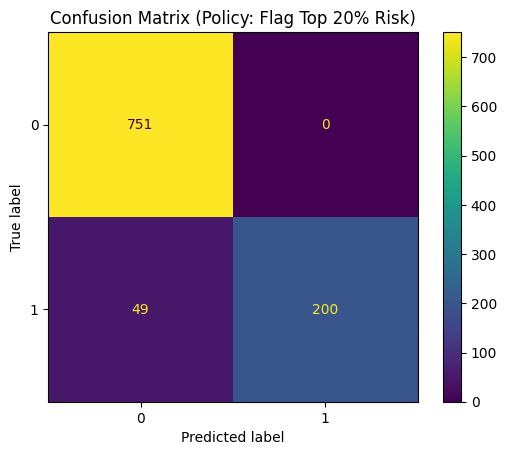

In [16]:
#top 20% confusion matrix
y_proba = final_model.predict_proba(X_test)[:, 1]
n = len(y_proba)
k = int(np.ceil(0.20 * n))

idx_sorted = np.argsort(y_proba)[::-1]
top_idx = idx_sorted[:k]
y_pred_topk = np.zeros(n, dtype=int)
y_pred_topk[top_idx] = 1

cm = confusion_matrix(y_test, y_pred_topk)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Policy: Flag Top 20% Risk)")
plt.show()

In [17]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision"
)

# Build readable feature list (original columns)
importances = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

importances.head(15)

,feature,importance_mean,importance_std
7,pack_years,0.160221,0.011251
24,xray_abnormal,0.012960,0.002263
0,age,0.012910,0.001768
13,copd,0.006005,0.000752
23,crp_level,0.005750,0.001598
9,air_pollution_index,0.005661,0.000989
12,family_history_cancer,0.004048,0.000646
10,occupational_exposure,0.002352,0.000463
16,chronic_cough,0.002154,0.000689
25,exercise_hours_per_week,0.001370,0.000264


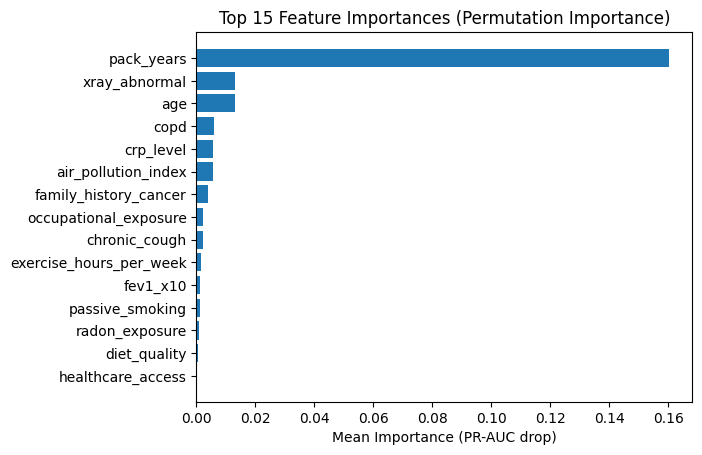

In [18]:
top = importances.head(15).iloc[::-1]
plt.figure()
plt.barh(top["feature"], top["importance_mean"])
plt.title("Top 15 Feature Importances (Permutation Importance)")
plt.xlabel("Mean Importance (PR-AUC drop)")
plt.show()

In [19]:
TP = cm[1, 1]
FP = cm[0, 1]

C = 50     # cost per outreach/screening invite (example)
B = 5000   # benefit per true high-risk correctly identified (example)

net_value = (TP * B) - ((TP + FP) * C)

print("True Positives (caught high-risk):", TP)
print("False Positives (unnecessary outreach):", FP)
print("Estimated net value (example): $", round(net_value, 2))

True Positives (caught high-risk): 200
False Positives (unnecessary outreach): 0
Estimated net value (example): $ 990000


Model Limitations

While the model achieved very strong predictive performance, several limitations must be acknowledged. The target variable, lung_cancer_risk, represents a risk classification rather than a confirmed medical diagnosis. This means the model is designed to support risk stratification, not to diagnose lung cancer.
Additionally, some clinical and lifestyle variables used as features may have contributed to how the risk label was originally constructed. This could result in inflated performance metrics and limits the model’s ability to generalize to datasets where risk is defined differently. As a result, model predictions should be interpreted cautiously and used only as part of a broader clinical decision-making process.
The dataset also represents a snapshot in time and may not fully capture changes in patient behavior or health status over time. Without longitudinal data, the model cannot account for how risk evolves.


Ethical Considerations

Because this model operates in a healthcare context, ethical considerations are especially important. Certain features, such as income level, education, and environmental exposure, may correlate with socioeconomic status. If not carefully monitored, the model could unintentionally reinforce existing health disparities by disproportionately flagging certain demographic groups.
False positives may lead to unnecessary anxiety or additional medical testing, while false negatives could result in missed opportunities for early intervention. For this reason, the model should be used as a decision-support tool rather than an automated decision-maker, with final screening decisions left to qualified healthcare professionals.
Transparency and explainability were prioritized to ensure that stakeholders can understand how predictions are made. Logistic Regression was selected in part because it allows clear interpretation of how individual factors contribute to risk, supporting responsible and ethical use.

Monitoring and real world deployment

If deployed in a real-world setting, this model would require ongoing monitoring and governance. Input data distributions should be regularly reviewed to detect data drift, particularly for behavioral variables such as smoking and exercise habits.
Model performance should be evaluated periodically as new outcome data becomes available, and retraining should occur if performance degrades or population characteristics change. Thresholds used for flagging high-risk individuals should also be reviewed to ensure alignment with operational capacity and clinical priorities.
The model should be integrated into existing healthcare workflows in a way that supports clinicians rather than replaces their judgment.

Final Conclusions and Recommendations

This project demonstrates how machine learning can be used to support lung cancer risk stratification by identifying individuals who may benefit from prioritized screening and preventive interventions. Using a structured CRISP-DM approach, multiple models were developed and evaluated, with Logistic Regression selected as the final model due to its strong performance and interpretability.
By targeting the top segment of highest-risk individuals, organizations can improve screening efficiency and better allocate limited healthcare resources. However, careful attention must be paid to ethical considerations, transparency, and ongoing monitoring to ensure responsible use.
Future work could include incorporating longitudinal data, external validation on independent datasets, and more detailed fairness analysis across demographic groups.